In [1]:
from obspy import *
from obspy.signal.cross_correlation import correlation_detector
import pandas as pd
import matplotlib.pyplot as plt
from obspy.clients.fdsn import Client
import matplotlib.dates as mdates
import numpy as np
import datetime

Installed new opener with handlers: [<urllib.request.HTTPDigestAuthHandler object at 0x349249d10>, <obspy.clients.fdsn.client.NoRedirectionHandler object at 0x3490394d0>]
Base URL: http://10.30.5.28:8080
Request Headers: {'User-Agent': 'ObsPy/1.5.0 (macOS-26.5.1-arm64-arm-64bit, Python 3.11.14)'}
Loading discovered services from cache.


/Users/kitsellusted/miniconda3/envs/pygmt-env/lib/python3.11/site-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)
/Users/kitsellusted/grad_school/VANDA_work/vnda_picker_orig.py:51: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client2.get_waveforms(


Downloaded http://10.30.5.28:8080/fdsnws/event/1/query?starttime=2025-11-24T00%3A11%3A30.000000&endtime=2025-11-24T00%3A12%3A30.000000&minmagnitude=5.0&maxmagnitude=9.0 with HTTP code: 204
No earthquakes for this time period.


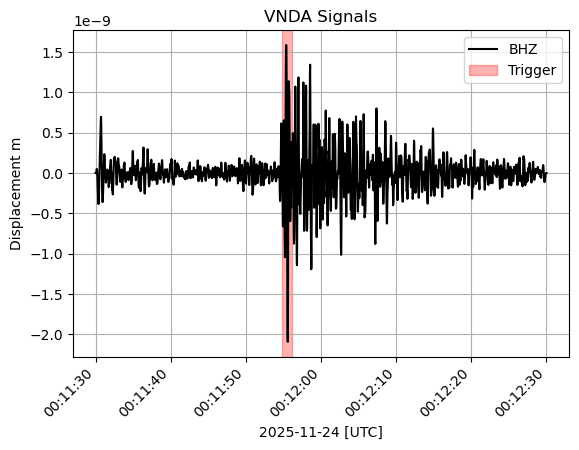

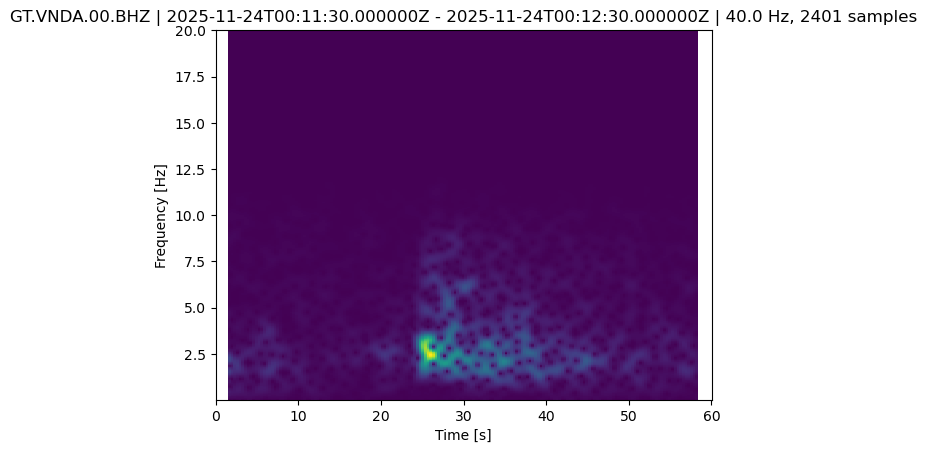

[None]

In [32]:
#Small slices: This is a visual check to see if the picker is selecting what want it to
#Very interesting. This is picking both the p and s-wave on the first run here. 

#%run vnda_picker_orig.py 2025-11-21T00:00 2025-11-23T00:00:00
#%run vnda_picker_orig.py 2025-11-22T01:44 2025-11-22T04:57:00
#%run vnda_picker_orig.py 2025-11-22T03:47 2025-11-22T03:49:00
#%run vnda_picker_orig.py 2025-11-25T02:08 2025-11-25T02:10:00
%run vnda_picker_orig.py 2025-11-24T00:11:30 2025-11-24T00:12:30
st.spectrogram()

Installed new opener with handlers: [<urllib.request.HTTPDigestAuthHandler object at 0x3490814d0>, <obspy.clients.fdsn.client.NoRedirectionHandler object at 0x33f9251d0>]
Base URL: http://10.30.5.28:8080
Request Headers: {'User-Agent': 'ObsPy/1.5.0 (macOS-26.5.1-arm64-arm-64bit, Python 3.11.14)'}
Loading discovered services from cache.


/Users/kitsellusted/miniconda3/envs/pygmt-env/lib/python3.11/site-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)
/Users/kitsellusted/grad_school/VANDA_work/vnda_picker_orig.py:51: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client2.get_waveforms(


Downloaded http://10.30.5.28:8080/fdsnws/event/1/query?starttime=2026-06-07T23%3A40%3A00.000000&endtime=2026-06-08T00%3A10%3A00.000000&minmagnitude=5.0&maxmagnitude=9.0 with HTTP code: 204
No earthquakes for this time period.
Thats a big one!


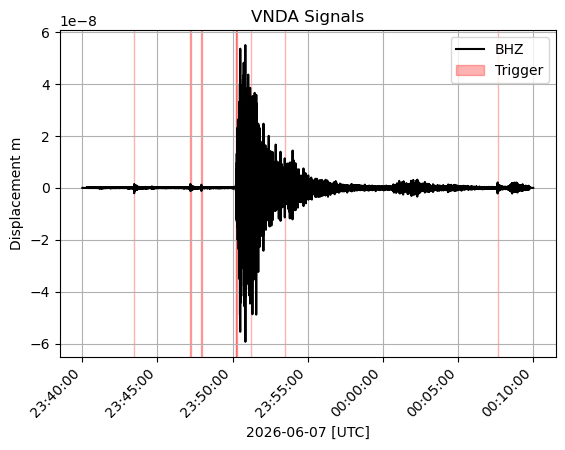

AttributeError: 'list' object has no attribute 'set_ylim'

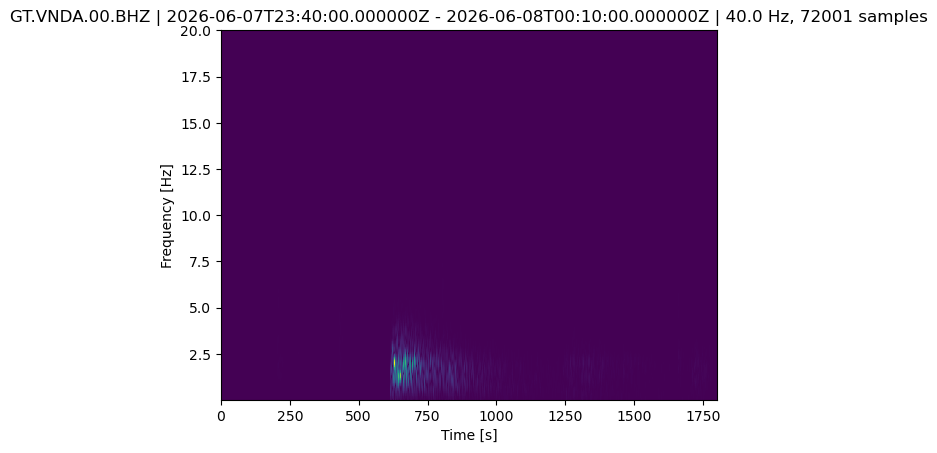

In [38]:
#Running the picker on the Philipines earthquake mww7.8. It says there are no earthquakes during the time period so obviously something is not working. Spectrogram looks different than some of the big ones" on the day plots
%run vnda_picker_orig.py 2026-06-07T23:40 2026-06-08T00:10:00
fig = st.spectrogram(show=False)
fig.set_ylim(1, 10)
plt.show()

In [11]:
def stat_plotter(df, df1):
    #Calculate hourly/daily metrics
    hourly_counts = df.groupby(df['local'].dt.hour).size() #in local time
    hour_utc = df.groupby(df['onset'].dt.hour).size() #UTC
    daily_counts = df.groupby(df['local'].dt.day).size() #in local time
    daily_utc = df.groupby(df['onset'].dt.day).size()
    
    #Checking if the two dfs are the same
    #Plot hourly variation of signal detection
    fig, ax = plt.subplots()
    ax.scatter(df['hour_local'].unique(), hourly_counts, label = 'unfiltered') #local time
    ax.set_xlabel('Hours in Local Time (UTC+13)')
    ax.set_ylabel('Number of Triggers')
    #ax.set_ylim(50,200)
    ax.scatter(df1['hour_local'].unique(), df1.groupby(df1['local'].dt.hour).size(), color = 'red', label = 'Filtered for double count') #local time
    ax.legend()
    fig.suptitle('Triggers Grouped by Time of Day unfiltered vs filtered')
    
    #plt.show()
    #this was a check to make sure they look the same and not clipping anything. Looks good. 
    
    #fig, ax = plt.subplots()
    #ax.scatter(df['hour_UTC'].unique(), hour_utc) #UTC time
    #ax.set_xlabel('Hours in UTc Time')
    #ax.set_ylabel('Number of Triggers')
    #ax.set_title('Triggers Grouped by Time of Day (UTC)')
    #plt.show()
    
    
    #pick_5 = daily_utc/(24*60) #event time put y-axis in pick per 5 ish min, or pick per minute
    fig, ax = plt.subplots()
    #ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), daily_utc)
    ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), daily_utc/(24), label = 'unfiltered') #pick per hour
    ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), df1.groupby(df1['onset'].dt.day).size()/24, color = 'red', label = 'Filtered for double count')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.set_xlabel('Days in UTC Time')
    #ax.set_ylim(5,15)
    ax.set_title("Average Number of Events per Hour")
    ax.set_ylabel('Number of Triggers per Hour')
    ax.legend()
    
    fig.tight_layout(pad=3.0) 

    fig.add_gridspec(4, 4, wspace=0, hspace=0)
   
    #interevent time plot
   
    fig, ax = plt.subplots()
    #ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), daily_utc)
    ax.hist(df['interevent_time'].dt.total_seconds()/60, bins = 80, edgecolor = 'black', label = 'unfiltered') 
    ax.hist(df1['interevent_time'].dt.total_seconds()/60, bins = 80, edgecolor = 'black', color = 'red', label = 'filtered')
    #ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.set_xlabel('Time in Minutes')
    ax.set_title("Interevent Spacing")
    ax.set_ylabel('Occurances')
    ax.legend()
    plt.show()

    fig, ax = plt.subplots()

    #ax = df.groupby(pd.Grouper(key='onset', freq='h')).size().plot(color = 'blue')
    hourly_counts = df1.groupby(pd.Grouper(key='onset', freq='h')).size()
    print(type(hourly_counts))
    ax = hourly_counts.plot(color = 'red', label = 'filtered')
    ax.set_xlabel('Days in UTC Time')
    ax.set_title("Number of Events per Hour")
    ax.set_ylabel('Triggers')
    #ax.set_ylim(0, 25)
    fig.tight_layout(pad=3.0) 
    fig.legend()
    fig.add_gridspec(8, 8, wspace=0, hspace=0)

    return None
    

In [12]:
def graphs(df):
    #Calculate hourly/daily metrics
    hourly_counts = df.groupby(df['local'].dt.hour).size() #in local time
    hour_utc = df.groupby(df['onset'].dt.hour).size() #UTC
    daily_counts = df.groupby(df['local'].dt.day).size() #in local time
    daily_utc = df.groupby(df['onset'].dt.day).size()
    print("the two dataframes are the same")
    
    #Plot hourly variation of signal detection
    fig, ax = plt.subplots()
    ax.scatter(df['hour_local'].unique(), hourly_counts, label = 'trigger counts', color = 'blue', edgecolors = 'black') #local time
    ax.set_xlabel('Hours in Local Time (UTC+13)')
    ax.set_ylabel('Number of Triggers')
    ax.legend()
    ax.set_ylim(40,100)
    fig.suptitle('Triggers Grouped by Time of Day')
    
    #Plot Average Number of Events per Hour
    fig, ax = plt.subplots()
    #ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), daily_utc)
    ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), daily_utc/(24), label = 'trigger counts', color = 'purple', edgecolor = 'black') #pick per hour
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.set_xlabel('Days in UTC Time')
    ax.set_ylim(5,12)
    ax.set_title("Average Number of Events per Hour")
    ax.set_ylabel('Number of Triggers per Hour')
    ax.legend()

    fig, ax = plt.subplots()
    #ax.scatter(pd.to_datetime(df['onset']).dt.date.unique(), daily_utc)
    ax.hist(df['interevent_time'].dt.total_seconds()/60, bins = 80, edgecolor = 'black', label = 'trigger counts') 
    ax.set_xlabel('Time in Minutes')
    ax.set_title("Interevent Spacing")
    ax.set_ylabel('Occurances')
    ax.legend()
    plt.show()

    fig, ax = plt.subplots()

    #ax = df.groupby(pd.Grouper(key='onset', freq='h')).size().plot(color = 'blue')
    hourly_counts = df.groupby(pd.Grouper(key='onset', freq='h')).size()
    ax = hourly_counts.plot(color = 'red', label = 'trigger counts')
    ax.set_xlabel('Days in UTC Time')
    ax.set_title("Number of Events per Hour")
    ax.set_ylabel('Triggers')
    ax.set_ylim(0, 25)
    fig.tight_layout(pad=3.0) 
    fig.legend()
    fig.add_gridspec(8, 8, wspace=0, hspace=0)
    return None

In [5]:
#Call vnda_picker_orig.py with the associated date range. This will output a list of trigger times. 
#I have the plottnig function of this set to False. Change to true to see the waveform/spectrogram
#CHANGE plot to FALSE otherwise it will be super messy
%run vnda_picker_orig.py 2025-11-21T00:00:00 2025-11-29T00:00:00


Installed new opener with handlers: [<urllib.request.HTTPDigestAuthHandler object at 0x178a72d90>, <obspy.clients.fdsn.client.NoRedirectionHandler object at 0x16e1647d0>]
Base URL: http://10.30.5.28:8080
Request Headers: {'User-Agent': 'ObsPy/1.5.0 (macOS-26.5.1-arm64-arm-64bit, Python 3.11.14)'}
Downloaded http://10.30.5.28:8080/fdsnws/station/1/application.wadl with HTTP code: 200
Downloaded http://10.30.5.28:8080/fdsnws/event/1/catalogs with HTTP code: 200
Downloaded http://10.30.5.28:8080/fdsnws/event/1/contributors with HTTP code: 200
Downloaded http://10.30.5.28:8080/fdsnws/event/1/application.wadl with HTTP code: 200
Downloaded http://10.30.5.28:8080/fdsnws/dataselect/1/application.wadl with HTTP code: 200
Discovered station service
Discovered event service
Discovered dataselect service
Storing discovered services in cache.


/Users/kitsellusted/miniconda3/envs/pygmt-env/lib/python3.11/site-packages/obspy/clients/fdsn/client.py:251: ObsPyDeprecationWarning: IRIS is now EarthScope, please consider changing the FDSN client short URL to 'EARTHSCOPE'.
  warnings.warn(msg, ObsPyDeprecationWarning)
/Users/kitsellusted/grad_school/VANDA_work/vnda_picker_orig.py:51: ObsPyDeprecationWarning: attach_response is deprecated and will be removed in a future release. Use remove_response() instead.
  st = client2.get_waveforms(


Downloaded http://10.30.5.28:8080/fdsnws/event/1/query?starttime=2025-11-21T00%3A00%3A00.000000&endtime=2025-11-29T00%3A00%3A00.000000&minmagnitude=5.0&maxmagnitude=9.0 with HTTP code: 204
No earthquakes for this time period.
Thats a big one!
Thats a big one!
Thats a big one!
Thats a big one!


In [6]:
#Trigger dataframe stuff
trigger_df = pd.DataFrame(trig_times)

#trigger_df.set_index()
trigger_df[0] = [t.datetime for t in trigger_df[0]]
trigger_df[1] = [t.datetime for t in trigger_df[1]]
trigger_df['month'] = trigger_df[0].dt.month
trigger_df['day'] = trigger_df[0].dt.day
trigger_df['hour_UTC'] = trigger_df[0].dt.hour

#Times in local Antarctica time, better for daylight tracking, diurnal patterns
trigger_df['local'] = trigger_df[0].dt.tz_localize('UTC').dt.tz_convert('Antarctica/McMurdo')
trigger_df['hour_local'] = trigger_df['local'].dt.hour
trigger_df['day_local'] = trigger_df['local'].dt.day
trigger_df.rename(columns={0:'onset', 1:'offset'}, inplace = True)

#Interevent spacing
trigger_df['interevent_time'] = trigger_df['onset'].shift(-1) - trigger_df['offset']

#Hourly and Daily counts
trigger_df["hourly_counts"] = trigger_df.groupby(trigger_df['local'].dt.hour).size() #in local time
hour_utc = trigger_df.groupby(trigger_df['onset'].dt.hour).size() #UTC
daily_counts = trigger_df.groupby(trigger_df['local'].dt.day).size() #in local time
daily_utc = trigger_df.groupby(trigger_df['onset'].dt.day).size()
trigger_df['amplitude m'] = pd.DataFrame(peak_amps) #amplitude - displacement in meters

#Filtered to no events under 1 minute 
filtered_df = trigger_df[trigger_df['interevent_time'].dt.total_seconds() > 60]

#trigger_df

In [7]:
unfilt_min = trigger_df['interevent_time'].dt.total_seconds()/60
filt_min = filtered_df['interevent_time'].dt.total_seconds()/60
print('unfiltered average interevent spacing:', round(unfilt_min.mean(),2), 'minutes')
#print('unfiltered std interevent spacing:', round(unfilt_min.std(),3), 'minutes')
#print('unfiltered mode interevent spacing:', round(unfilt_min.mode(),3), 'minutes')

print('filtered average interevent spacing:', round(filt_min.mean(),2), 'minutes')
#print('filtered std interevent spacing:', round(filt_min.std(),3), 'minutes')
#print('filtered mode interevent spacing:', round(filt_min.mode(),3), 'minutes')


unfiltered average interevent spacing: 7.16 minutes
filtered average interevent spacing: 7.24 minutes


the two dataframes are the same


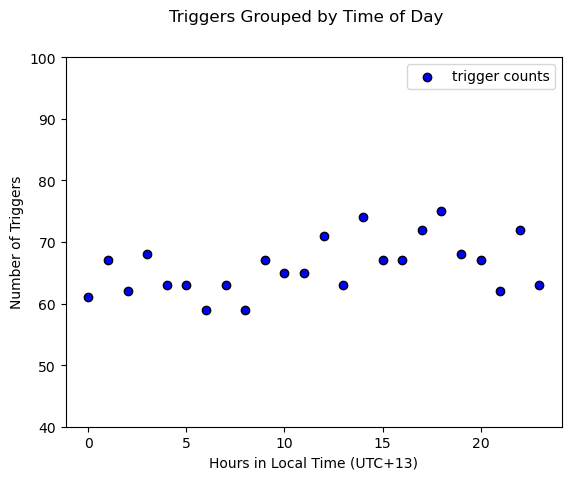

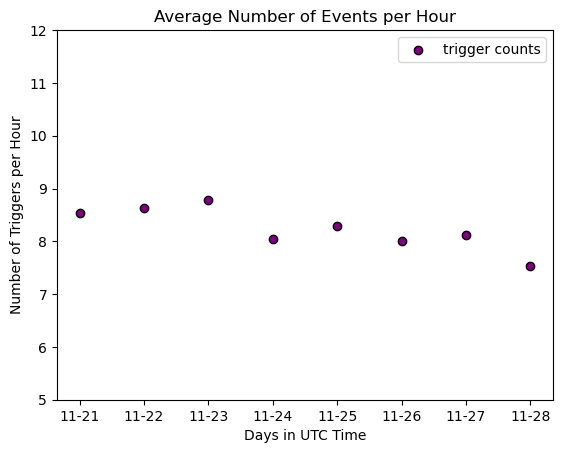

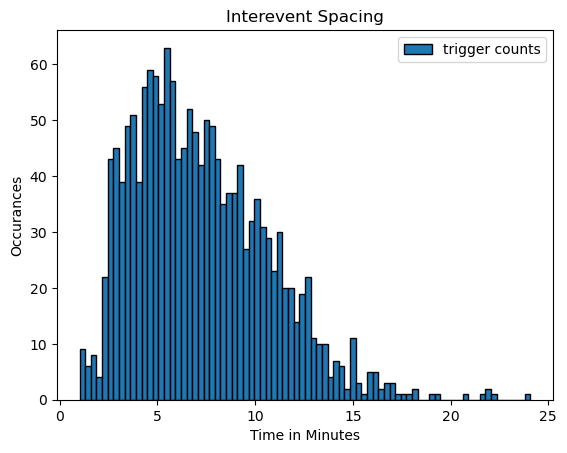

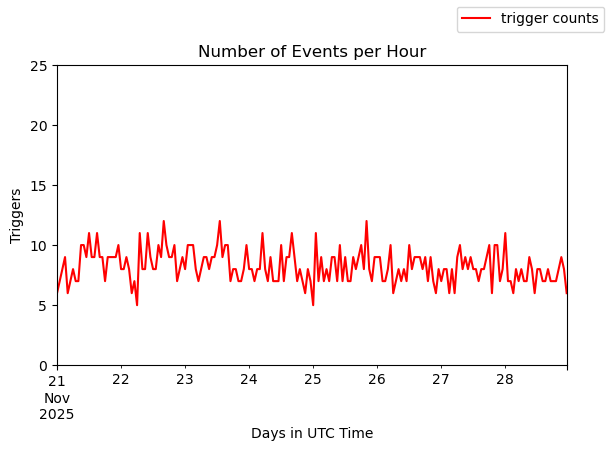

In [13]:
# COMPARING THE FILTERED VS. UNFILTERED TRIGGER PICKS. FILTERING BY TIME INBETWEEN TRIGGERS
#adding in the additional filter by amplitude reduces the likelihood of double picking!
#stat_plotter(trigger_df, filtered_df)
graphs(filtered_df)

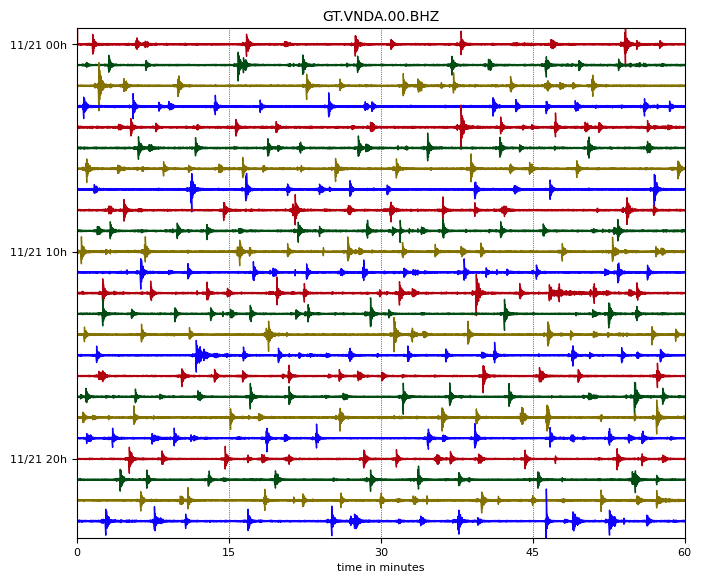

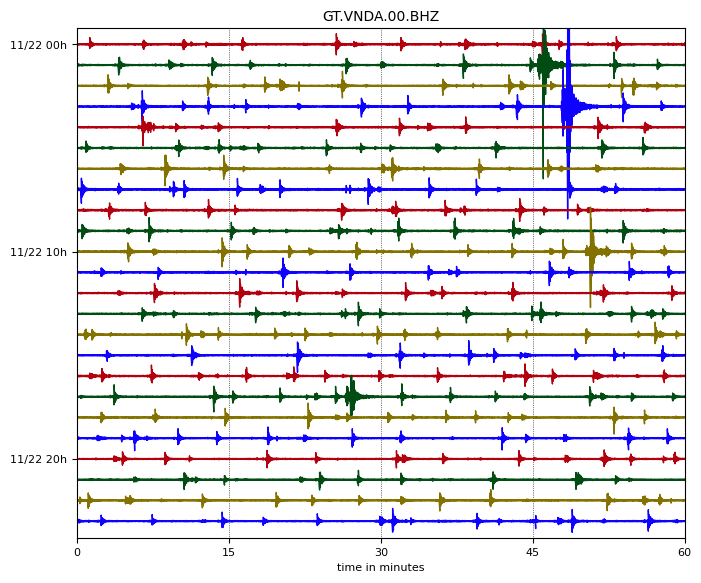

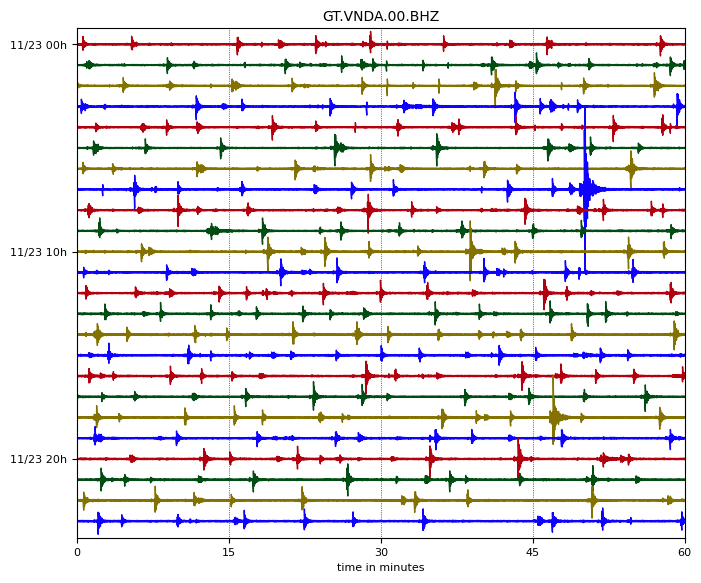

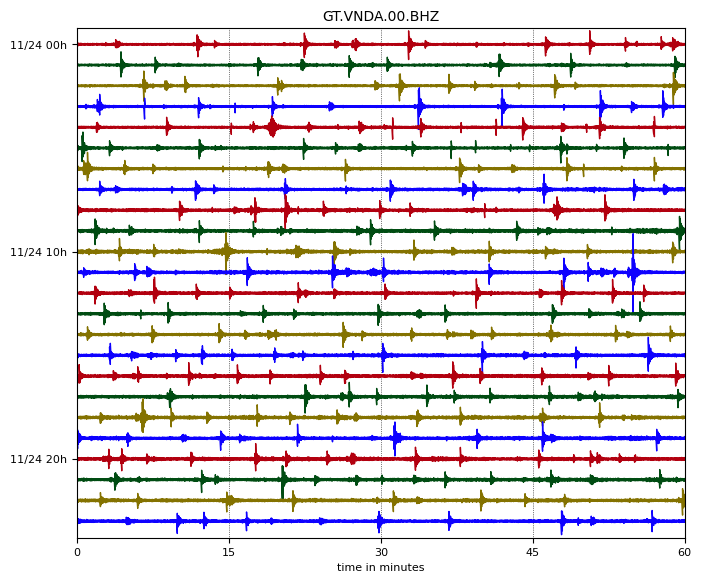

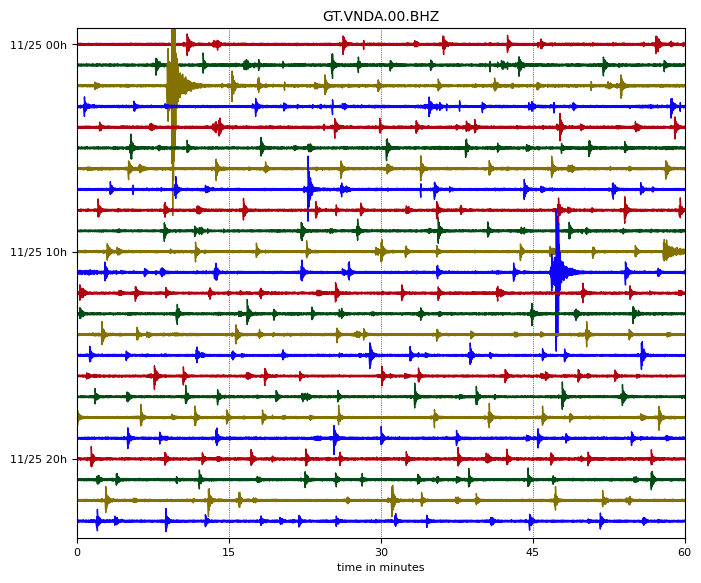

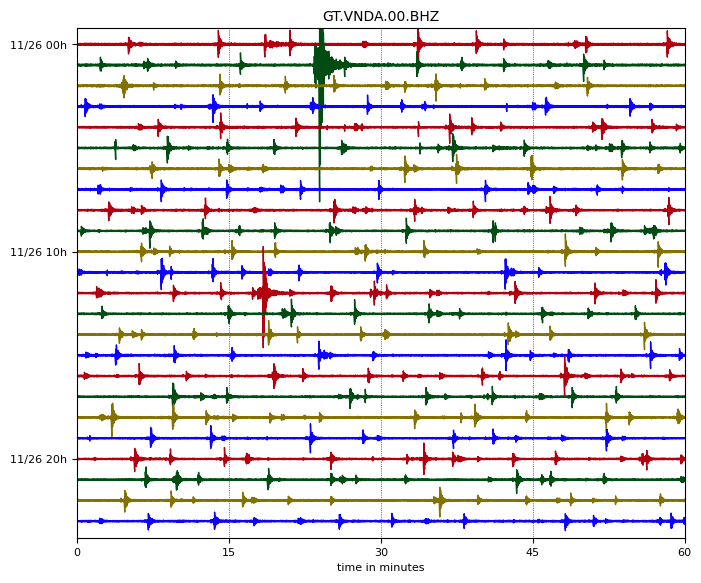

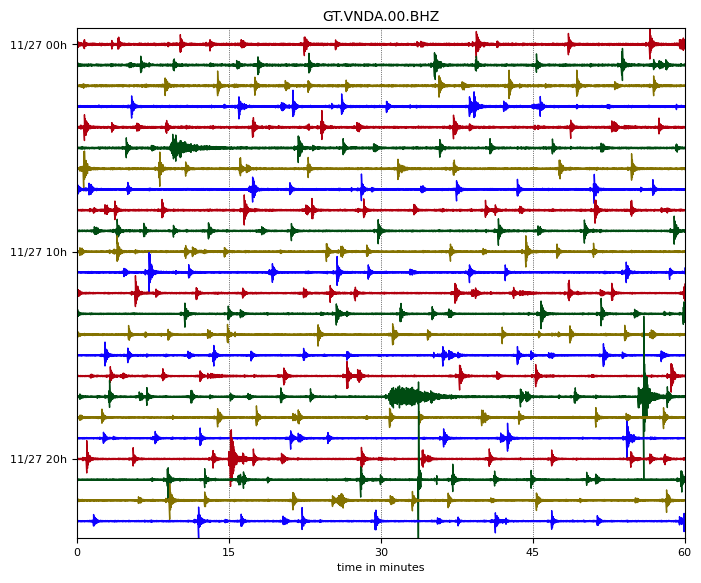

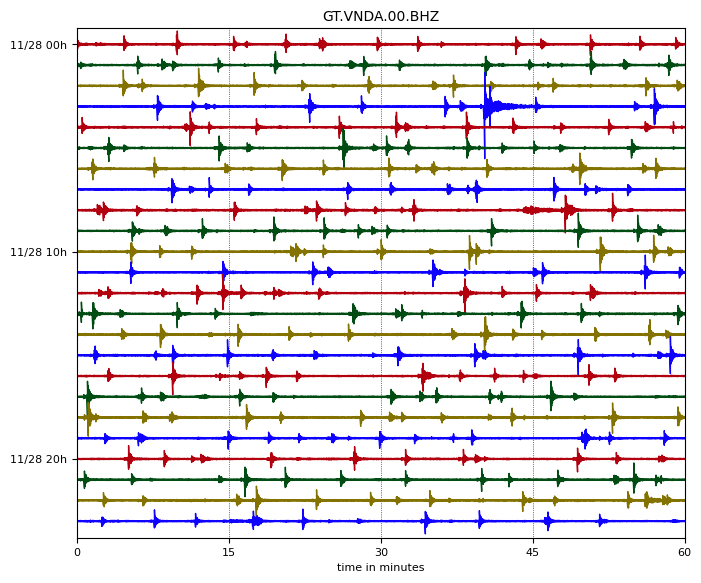

stream is less than 1 day. this will not work


In [16]:
#Dayplots
if st[0].stats.endtime - st[0].stats.starttime >= 24*60*60:
    for tr in st:
        for i in range(len(pd.to_datetime(trigger_df['onset']).dt.date.unique())):
            start_time = st[0].stats.starttime
            day_start = start_time + (i * 86400)
            day_end = day_start + 86400
            daily_st = st.slice(day_start, day_end)
    
            local_offset = +13 * 3600
            daily_st.plot(type='dayplot', interval=60, tick_format='%m/%d %Hh', 
                          offset=local_offset,
                          show_y_UTC_label=False  )# interval is minutes per line
        else:
            print('stream is less than 1 day. this will not work')
            
            


IndexError: Empty stream object

0 Trace(s) in Stream:


## Preparing for Template Matching ##

In [ ]:
st

In [ ]:
len(sliced_wvf)
plt.plot(sliced_wvf[1])

In [ ]:
#%run vnda_picker_orig.py 2025-11-21T00:00:00 2025-11-21T03:00:00
#detections, sims = correlation_detector(st, Stream(sliced_wvf[0]), 0.2, 1, plot = template)


In [ ]:
len(sliced_wvf)
plt.plot(sliced_wvf[14])

In [ ]:
print("onsettime", ' / ', "Index in sliced_wvf", " / ", "Number of Hits with this Wiggle")
hr = st[0].slice(st[0].stats.starttime, st[0].stats.starttime+3600/2)
hr.filter("bandpass", freqmin=2, freqmax=10)
for onset in range(len(trigger_df) - len(trigger_df)+20):
    #print(onset)
    #template = Stream(st.slice(UTCDateTime(trigger_df.iat[onset,0]) - 60, UTCDateTime(trigger_df.iat[onset,1])+60))
    for wiggle in sliced_wvf:
        wiggle = Stream(wiggle)
        height = 0.2  # similarity threshold, Probably adjust
        distance = 2  # distance between detections in seconds, probably adjust
    
        detections, sims = correlation_detector(Stream(hr), wiggle, height, distance)
        #print('here')
        if len(detections)>1:
            print("hr:",  st[0].stats.starttime, "to", st[0].stats.starttime+3600)
            print(wiggle[0].stats.starttime, sliced_wvf.index(wiggle[0]),len(detections))
            #wiggle.plot()
    
        else:
            pass
    #template.plot()

In [ ]:
print("onsettime", ' / ', "Index in sliced_wvf", " / ", "Number of Hits with this Wiggle")
#template = st.slice(UTCDateTime(trigger_df.iat[0,0]) - 60, UTCDateTime(trigger_df.iat[0,1])+60)
for wiggle in sliced_wvf:
    wiggle = Stream(wiggle)
    #hr = test.slice(st[0].stats.starttime, test.stats.endtime)
    #hr.filter("bandpass", freqmin=2, freqmax=10)
    height = 0.2  # similarity threshold, Probably adjust
    distance = 1  # distance between detections in seconds, probably adjust

    detections, sims = correlation_detector(st, wiggle, height, distance)
    #print('here')
    if len(detections)>0:
        print(wiggle[0].stats.starttime, sliced_wvf.index(wiggle[0]),len(detections))
        #wiggle.plot()

    else:
        pass

In [ ]:
#%run vnda_picker_orig.py 2025-11-21T00:00 2025-11-21T01:00:00
print(len(sliced_wvf))
print("onsettime", ' / ', "Index in sliced_wvf", " / ", "Number of Hits with this Wiggle")
i = 0
for wiggle in sliced_wvf:
    wiggle = Stream(wiggle)
    hr_offset = st[0].stats.starttime+i*3600
    hr_onset = st[0].stats.starttime+i
    hr = st.slice(hr_onset, hr_offset)
    hr.filter("bandpass", freqmin=2, freqmax=10)
    hr.taper(0.01)

    height = 0.2  # similarity threshold, Probably adjust
    distance = 10  # distance between detections in seconds, probably adjust

    detections, sims = correlation_detector(hr, wiggle, height, distance)
    #print('here')
    if len(detections)>0:
        print(wiggle[0].stats.starttime, sliced_wvf.index(wiggle[0]),len(detections))
        wiggle.plot()
        correlation_detector(hr, wiggle, height, distance, plot = hr)
    else:
        pass
    hr_onset = hr_offset
    i = i+1

In [ ]:
#Using Obspy corss-correlation detector
#Manually picked template wiggles

wiggle_1 = Stream(sliced_wvf[14]) #wiggles need to be in stream() form, 
wiggle_1.plot()
plt.show()

#testing on 1 hour of data
hr = st.slice(st[0].stats.starttime, st[0].stats.endtime)
#hr.filter("bandpass", freqmin=2, freqmax=10)
height = 0.1  # similarity threshold, Probably adjust, ISTHIS TOO LOW?
distance = 120  # distance between detections in seconds, probably adjust
st[0].data = np.nan_to_num(st[0].data)
detections, sims = correlation_detector(st, wiggle_1, height, distance)
print(len(detections), st)